#1. Library Imports

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

In [11]:
plt.rcParams['figure.figsize'] = (12,8)

In [12]:
df = pd.read_csv('employee_data (1).csv')
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,quit,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0.0,sales,low
1,0.80,0.86,5,262,6,0,1,0.0,sales,medium
2,0.11,0.88,7,272,4,0,1,0.0,sales,medium
3,0.72,0.87,5,223,5,0,1,0.0,sales,low
4,0.37,0.52,2,159,3,0,1,0.0,sales,low


#2. Exploratory Data Analysis

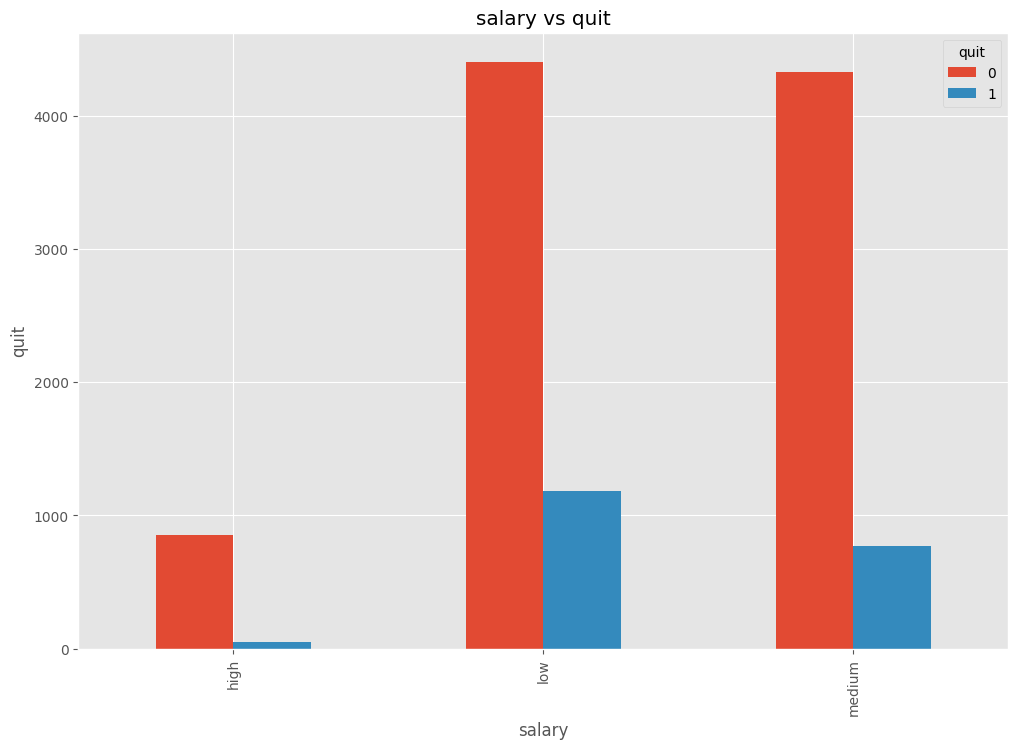

In [14]:
pd.crosstab(df.salary,df.quit).plot(kind = 'bar')
plt.title('salary vs quit')
plt.xlabel('salary')
plt.ylabel('quit')
plt.show()

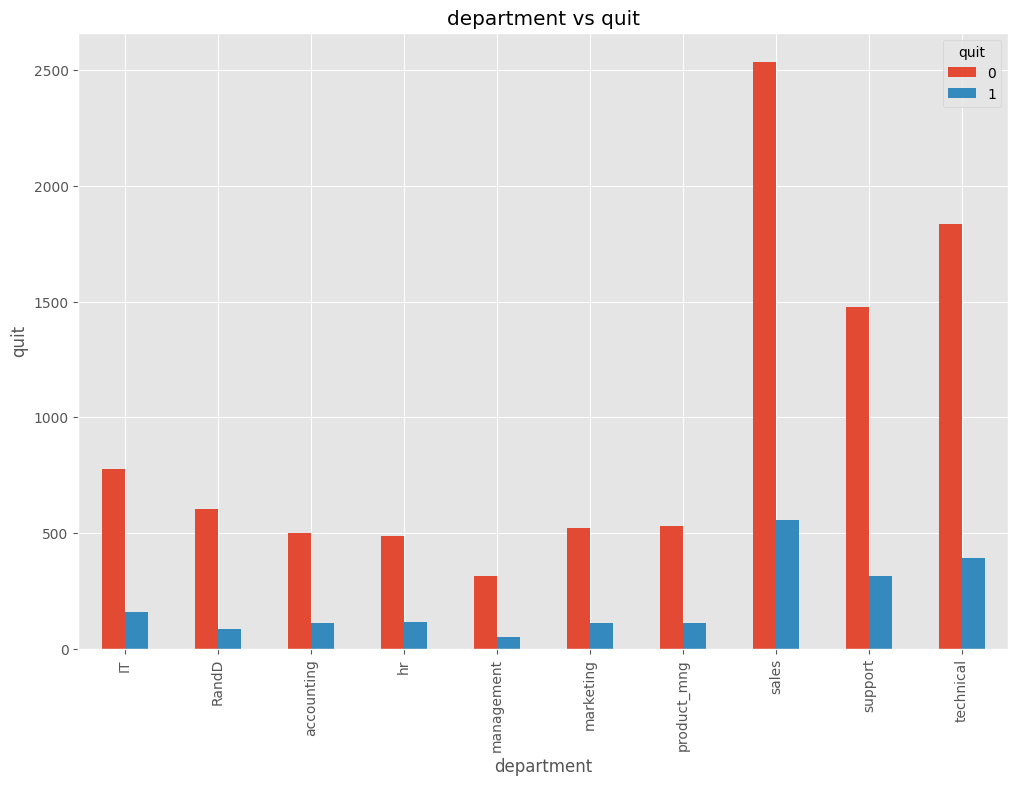

In [15]:
pd.crosstab(df.department,df.quit).plot(kind = 'bar')
plt.title('department vs quit')
plt.xlabel('department')
plt.ylabel('quit')
plt.show()

#3. Data Preprocessing

In [16]:
cat_vars=['department','salary']
for i in cat_vars:
    cat_list=pd.get_dummies(df[i], prefix=i)
    df=df.join(cat_list)


In [17]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,quit,promotion_last_5years,department,salary,...,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,salary_high,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0.0,sales,low,...,False,False,False,False,True,False,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0.0,sales,medium,...,False,False,False,False,True,False,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0.0,sales,medium,...,False,False,False,False,True,False,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0.0,sales,low,...,False,False,False,False,True,False,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0.0,sales,low,...,False,False,False,False,True,False,False,False,True,False


In [18]:
df.drop(['department','salary'],axis = 1, inplace = True)

#4. Visualize Class Imbalance

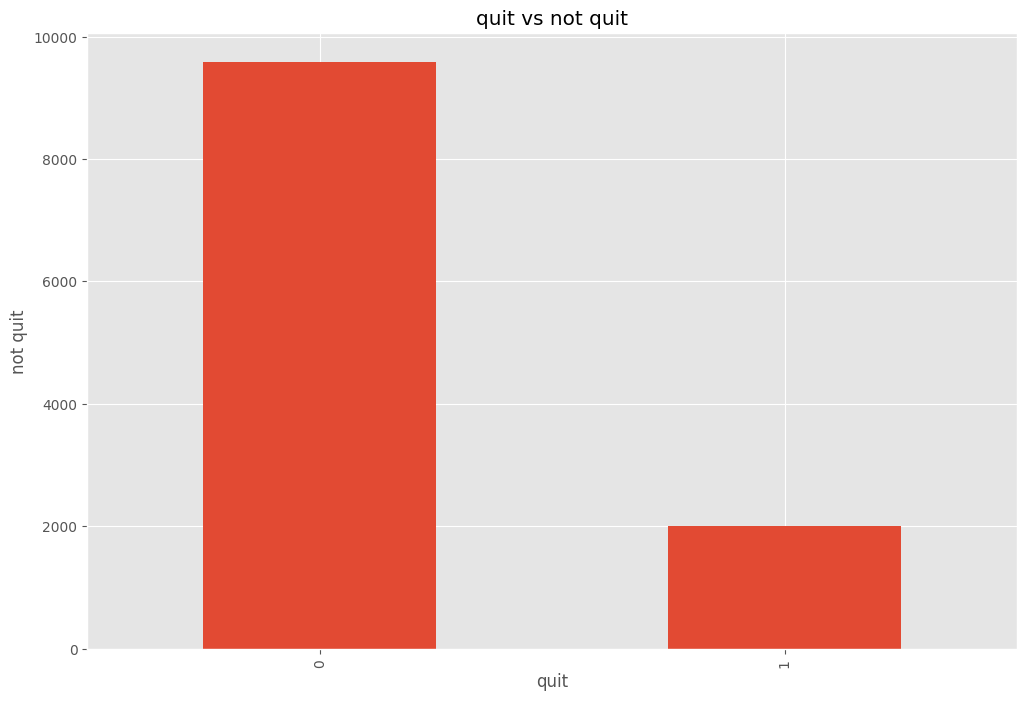

In [20]:
df.quit.value_counts().plot(kind = 'bar')
plt.title('quit vs not quit')
plt.xlabel('quit')
plt.ylabel('not quit')
plt.show()

#5: Create Training and Test Sets

In [21]:
x=df.loc[:,df.columns !='quit']
y=df.quit

#6. Model Building

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [26]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state = 123, stratify= y )

In [27]:
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()

In [28]:
dt.fit(x_train,y_train)
rf.fit(x_train,y_train)

RandomForestClassifier()

#7. Model Evaluation

In [35]:
y_pred_dt = dt.predict(x_test)
y_pred_rf = rf.predict(x_test)
print(f"Decision Tree Acuuracy : {accuracy_score(y_test,y_pred_dt)}")
print(f"Random Forest Acuuracy : {accuracy_score(y_test,y_pred_rf)}")

Decision Tree Acuuracy : 0.9675414364640884
Random Forest Acuuracy : 0.9816988950276243


In [40]:
print(f"DT : {classification_report(y_test,y_pred_dt)}")
print()
print(f"RF : {classification_report(y_test,y_pred_rf)}")

DT :               precision    recall  f1-score   support

           0       0.98      0.98      0.98      2396
           1       0.91      0.90      0.91       500

    accuracy                           0.97      2896
   macro avg       0.95      0.94      0.94      2896
weighted avg       0.97      0.97      0.97      2896


RF :               precision    recall  f1-score   support

           0       0.98      1.00      0.99      2396
           1       0.99      0.90      0.94       500

    accuracy                           0.98      2896
   macro avg       0.98      0.95      0.97      2896
weighted avg       0.98      0.98      0.98      2896



#8. Feature Importance

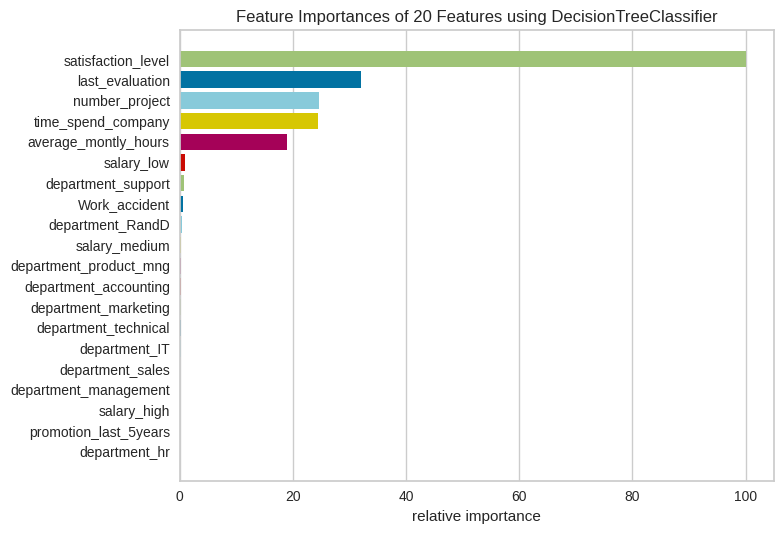

<Axes: title={'center': 'Feature Importances of 20 Features using DecisionTreeClassifier'}, xlabel='relative importance'>

In [32]:
from yellowbrick.model_selection import FeatureImportances
dt_imp = FeatureImportances(dt)
dt_imp.fit(x_train,y_train)
dt_imp.show()

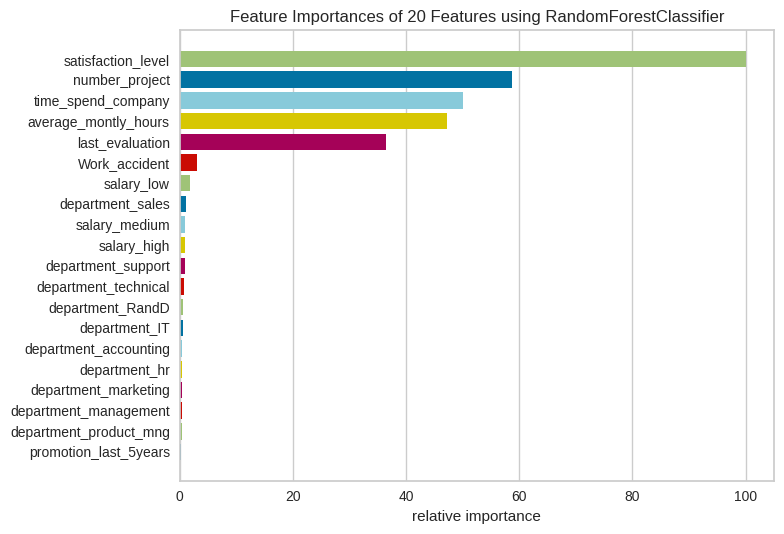

<Axes: title={'center': 'Feature Importances of 20 Features using RandomForestClassifier'}, xlabel='relative importance'>

In [36]:
from yellowbrick.model_selection import FeatureImportances
dt_imp = FeatureImportances(rf)
dt_imp.fit(x_train,y_train)
dt_imp.show()

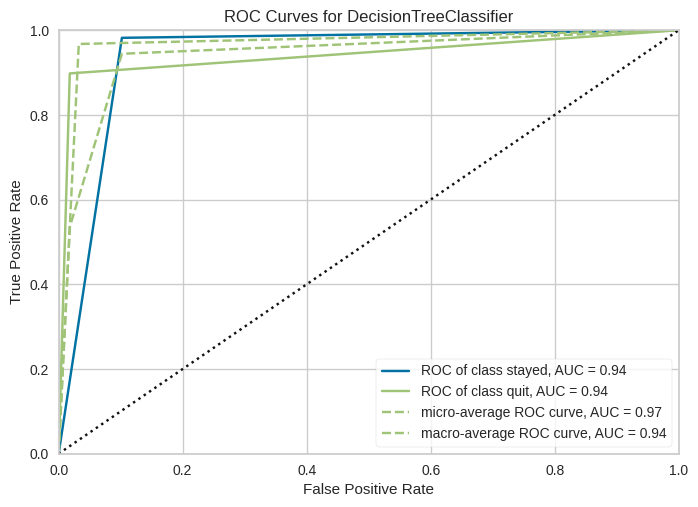

<Axes: title={'center': 'ROC Curves for DecisionTreeClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [37]:
from yellowbrick.classifier import ROCAUC

visualizer=ROCAUC(dt,classes=['stayed','quit'])
visualizer.fit(x_train,y_train)
visualizer.score(x_test,y_test)
visualizer.poof()

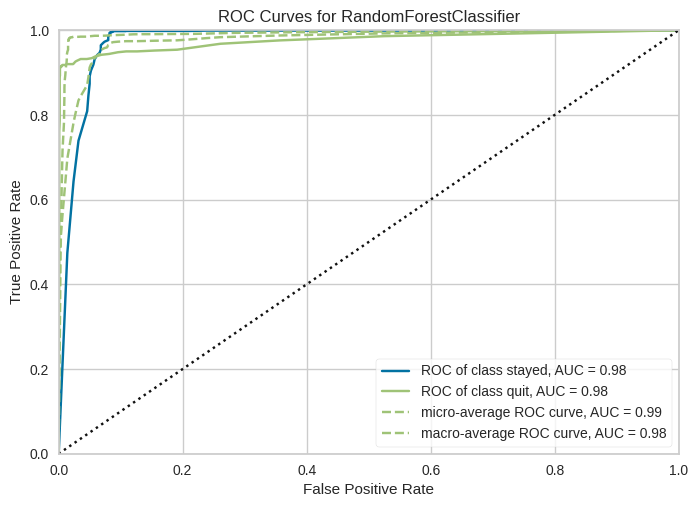

<Axes: title={'center': 'ROC Curves for RandomForestClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [38]:
from yellowbrick.classifier import ROCAUC

visualizer=ROCAUC(rf,classes=['stayed','quit'])
visualizer.fit(x_train,y_train)
visualizer.score(x_test,y_test)
visualizer.poof()

In [44]:
import joblib
joblib.dump(dt,'dt_model.sav')
joblib.dump(rf,'rf_model.sav')

['rf_model.sav']